# Customer Retention Analysis

This notebook visualizes customer retention across cohorts based on the month of each customer's first observed transaction.

The retention metrics are calculated in PostgreSQL and accessed through the `analytics.cohort_retention` view. Python is used to transform the results into a retention matrix and visualize cohort behavior over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from finsight.database import (
    connect_to_database,
    test_database_connection,
)

In [2]:
engine = connect_to_database()
test_database_connection(engine)

Connected!


In [3]:
query = """
select *
from analytics.cohort_retention
order by cohort_month, months_since_first_transaction
"""

df = pd.read_sql(query, engine)
df["cohort_month"] = pd.to_datetime(df["cohort_month"])

In [4]:
df.head()

,cohort_month,months_since_first_transaction,active_customers,cohort_size,retention_rate
0,2010-01-01,0.0,1083,1083,100.0
1,2010-01-01,1.0,1083,1083,100.0
2,2010-01-01,2.0,1083,1083,100.0
3,2010-01-01,3.0,1083,1083,100.0
4,2010-01-01,4.0,1083,1083,100.0


In [5]:
retention_matrix = pd.pivot_table(
    df,
    index="cohort_month",
    columns="months_since_first_transaction",
    values="retention_rate"
)

In [6]:
retention_matrix.head()

months_since_first_transaction,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,108.0,109.0,110.0,111.0,112.0,113.0,114.0,115.0,116.0,117.0
cohort_month,,,,,,,,,,,,,,,,,,,,,
2010-01-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,99.91,99.91,99.91,...,98.8,98.8,98.89,98.89,98.89,98.89,98.89,98.89,98.89,98.61
2010-02-01,100.0,71.43,78.57,78.57,92.86,92.86,92.86,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,NaN
2010-03-01,100.0,75.00,75.00,75.00,75.00,75.00,75.00,75.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,NaN,NaN
2010-04-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,100.00,NaN,NaN,NaN
2010-05-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,100.0,100.0,100.00,100.00,100.00,100.00,NaN,NaN,NaN,NaN


The `cohort_retention` view returns only months in which at least one customer from a cohort was active. After pivoting, months without any activity appear as missing values. Since every cohort has at least 12 months of observation (the latest cohort starts in 2017 and data is available until October 2019), these missing values represent 0% retention rather than missing data and are filled with zero.

In [7]:
retention_12m = retention_matrix.iloc[:, :12].fillna(0)

In [8]:
retention_12m.head()

months_since_first_transaction,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
cohort_month,,,,,,,,,,,,
2010-01-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,99.91,99.91,99.91,99.91,99.91
2010-02-01,100.0,71.43,78.57,78.57,92.86,92.86,92.86,100.00,100.00,100.00,100.00,100.00
2010-03-01,100.0,75.00,75.00,75.00,75.00,75.00,75.00,75.00,100.00,100.00,100.00,100.00
2010-04-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2010-05-01,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


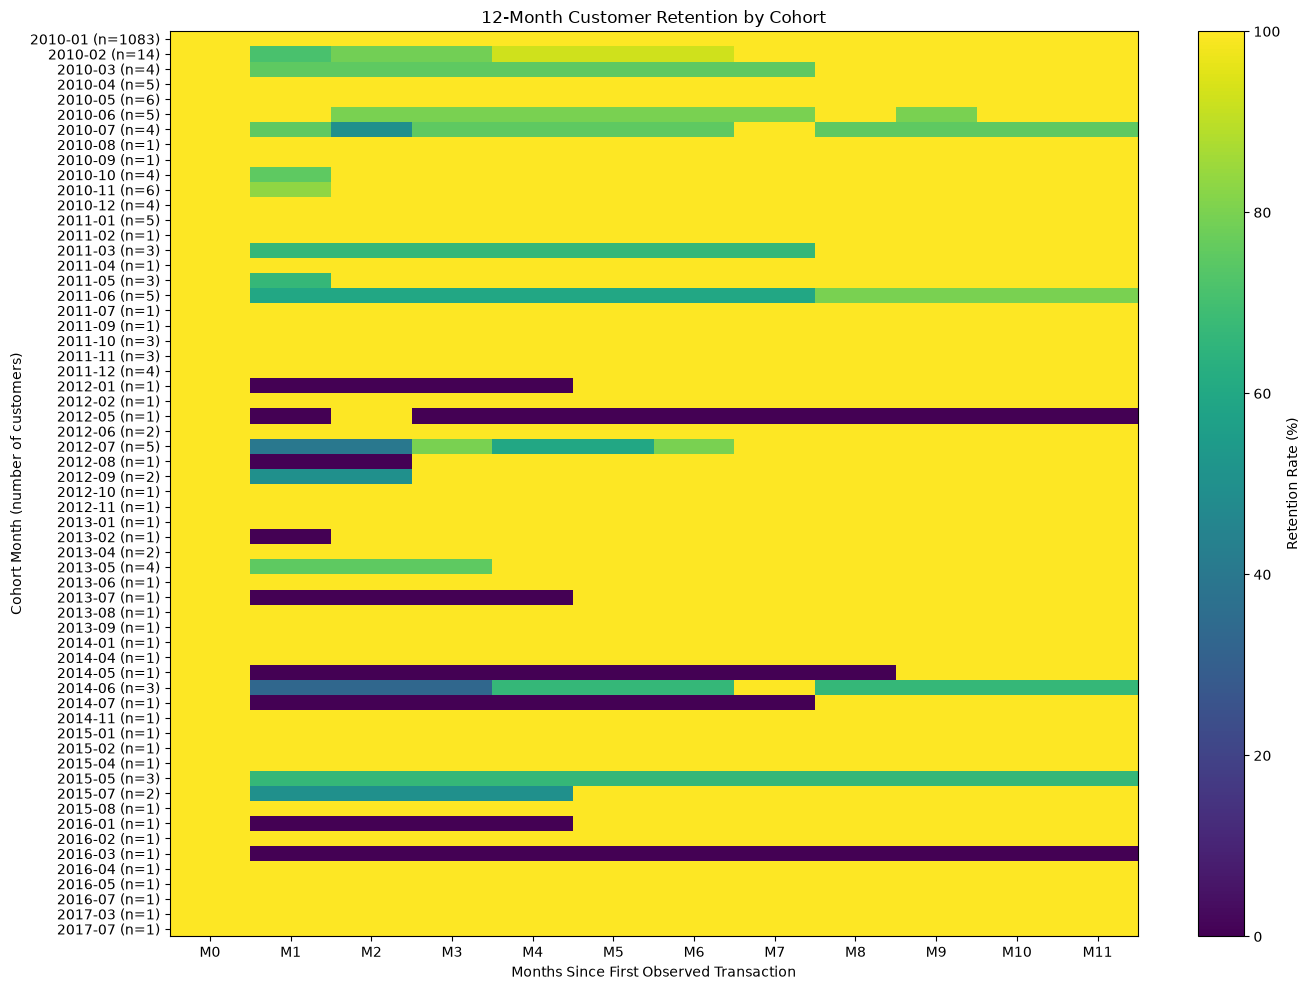

In [9]:
cohort_sizes = df.groupby("cohort_month")["cohort_size"].first()

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(
    retention_12m,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=100
)

fig.colorbar(
    im,
    ax=ax,
    label="Retention Rate (%)"
)

ax.set_title("12-Month Customer Retention by Cohort")
ax.set_xlabel("Months Since First Observed Transaction")
ax.set_ylabel("Cohort Month (number of customers)")

ax.set_xticks(range(retention_12m.shape[1]))
ax.set_xticklabels(
    [f"M{int(col)}" for col in retention_12m.columns]
)

ax.set_yticks(range(retention_12m.shape[0]))
ax.set_yticklabels(
    [f"{date.strftime('%Y-%m')} (n={cohort_sizes[date]})" for date in retention_12m.index]
)

plt.tight_layout()
plt.show()

## Retention Analysis Summary

- The first cohort (2010-01) contains 1,083 of the 1,219 customers with transaction history (88.8%) and remains close to 100% active throughout the first year. This reflects that most customers were already active when the observation period began, so their first observed transaction is not their true acquisition date.
- The remaining 136 customers are spread across many small cohorts, most of them containing only a single customer. In these cohorts, a single inactive customer changes the retention rate by tens of percentage points, so month-to-month variation should not be interpreted as a meaningful trend.
- Months in which no customer from a cohort was active are shown as 0% retention.

Because of these limitations, the dataset is not suitable for measuring true customer acquisition and retention. The heatmap primarily illustrates the structure of the observation period rather than customer loyalty, consistent with the RFM and repeat activity findings in `docs/business_insights.md`.